# Task 4 — Portfolio Optimization (Modern Portfolio Theory)

Combines the Task 3 LSTM 12-month forecast for TSLA with historical returns
for BND/SPY to build an expected returns vector and covariance matrix, then
solves for the Maximum Sharpe Ratio and Minimum Volatility portfolios using
PyPortfolioOpt.

**Note on TSLA's forecast:** Task 3 found a huge confidence cone around the
central +97%/yr drift estimate. An unconstrained optimizer, taking that
point estimate at face value, will concentrate almost entirely in TSLA —
which defeats the purpose of diversification and ignores the very
uncertainty Task 3 flagged. We solve both an unconstrained version (to show
this concretely) and a capped version (max 50% per asset) as the actual
recommendation.

In [11]:
import sys, pathlib
cwd = pathlib.Path('.').resolve()
if (cwd / 'src').exists():
    sys.path.insert(0, str(cwd))
else:
    p = cwd
    while p.parent != p:
        p = p.parent
        if (p / 'src').exists():
            sys.path.insert(0, str(p))
            break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
from src.portfolio_utils import (
    load_portfolio_data, load_tsla_forecast_return, build_expected_returns,
    build_covariance_matrix, monte_carlo_cloud, solve_portfolio,
    save_portfolio_results
)
importlib.reload(sys.modules['src.portfolio_utils'])


plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

TICKERS = ['TSLA', 'BND', 'SPY']
START_DATE = '2015-01-01'
TRAIN_END = '2024-12-31'
RISK_FREE_RATE = 0.045   # approx. current T-bill yield; adjust if you have a more current figure
CAP = 0.50                # max weight per asset in the "capped" scenario

---
## Section 1 — Load Historical Data (Training Period Only)

Restricted to pre-test-period data, consistent with the chronological
split used throughout Task 2 — avoids look-ahead bias.

In [12]:
prices, returns = load_portfolio_data(TICKERS, START_DATE, TRAIN_END)
print(f'Portfolio data: {len(prices)} trading days ({prices.index[0].date()} -> {prices.index[-1].date()})')

hi
  Found existing raw file: ../data/raw/TSLA_raw.csv
  Found existing raw file: ../data/raw/BND_raw.csv
  Found existing raw file: ../data/raw/SPY_raw.csv
Portfolio data: 2888 trading days (2015-01-02 -> 2026-06-29)


---
## Section 2 — Expected Returns Vector (mu)

TSLA: annualized return implied by the Task 3 LSTM 12-month forecast.
BND, SPY: historical annualized average daily return.

In [13]:
tsla_annual_return, first_fc_price, last_fc_price = load_tsla_forecast_return()
mu_vec = build_expected_returns(returns, TICKERS, tsla_annual_return)

print(f'Task 3 forecast: ${first_fc_price:.2f} -> ${last_fc_price:.2f} over 12 months')
print()
print('Expected Annual Returns (mu):')
for t in TICKERS:
    source = 'LSTM forecast (Task 3)' if t == 'TSLA' else 'historical average'
    print(f'  {t}: {mu_vec[t]*100:7.2f}%   ({source})')

Task 3 forecast: $412.43 -> $812.37 over 12 months

Expected Annual Returns (mu):
  TSLA:   96.97%   (LSTM forecast (Task 3))
  BND:    2.00%   (historical average)
  SPY:   14.43%   (historical average)


---
## Section 3 — Covariance Matrix

In [14]:
cov_matrix = build_covariance_matrix(returns)

print('Annualized Covariance Matrix:')
print(cov_matrix.round(4))
print()
print('Correlation Matrix:')
print(returns.corr().round(3))

Annualized Covariance Matrix:
        TSLA     BND     SPY
TSLA  0.3269  0.0018  0.0498
BND   0.0018  0.0028  0.0011
SPY   0.0498  0.0011  0.0312

Correlation Matrix:
       TSLA    BND    SPY
TSLA  1.000  0.059  0.494
BND   0.059  1.000  0.116
SPY   0.494  0.116  1.000


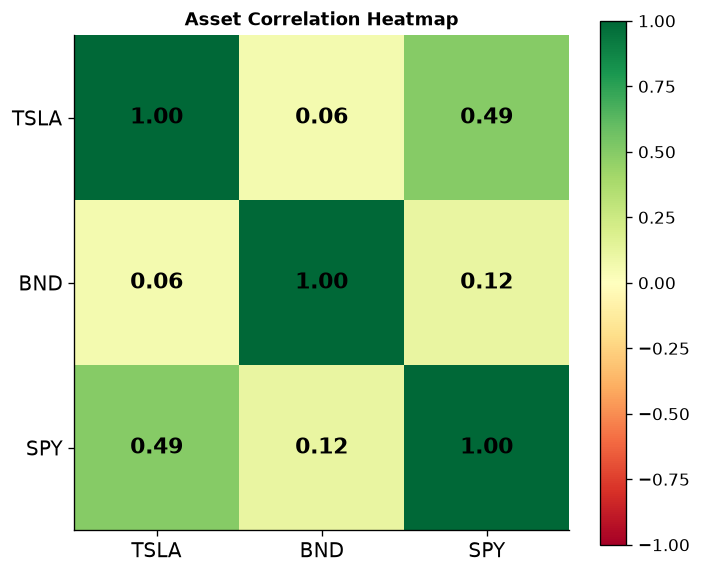

In [15]:
corr = returns.corr()
fig, ax = plt.subplots(figsize=(6, 5))
img = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(img, ax=ax)
ax.set_xticks(range(3)); ax.set_xticklabels(TICKERS, fontsize=12)
ax.set_yticks(range(3)); ax.set_yticklabels(TICKERS, fontsize=12)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=13, fontweight='bold')
ax.set_title('Asset Correlation Heatmap', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 4 — Unconstrained Optimization (Diagnostic)

Solving without weight caps, to show concretely what happens when the
optimizer takes TSLA's +97%/yr point estimate at face value, ignoring the
huge uncertainty around it found in Task 3.

In [16]:
results_unconstrained = solve_portfolio(mu_vec, cov_matrix, risk_free_rate=RISK_FREE_RATE,
                                          weight_bounds=(0, 1))

print('=== UNCONSTRAINED — Max Sharpe Portfolio ===')
for t, w in results_unconstrained['max_sharpe']['weights'].items():
    print(f'  {t}: {w*100:.1f}%')
print(f"  Return: {results_unconstrained['max_sharpe']['return']*100:.2f}%  "
      f"Volatility: {results_unconstrained['max_sharpe']['volatility']*100:.2f}%  "
      f"Sharpe: {results_unconstrained['max_sharpe']['sharpe']:.2f}")
print()
print('This concentration illustrates why the raw forecast should not be used')
print('unconstrained: it ignores the wide confidence cone from Task 3 entirely.')

=== UNCONSTRAINED — Max Sharpe Portfolio ===
  TSLA: 100.0%
  BND: 0.0%
  SPY: 0.0%
  Return: 96.97%  Volatility: 57.18%  Sharpe: 1.62

This concentration illustrates why the raw forecast should not be used
unconstrained: it ignores the wide confidence cone from Task 3 entirely.


In [17]:
import numpy
import pypfopt
print(numpy.__version__)
print(pypfopt.__version__)

2.4.6
1.6.0


---
## Section 5 — Capped Optimization (Recommended)

Applying a 50% max weight per asset — a standard concentration-risk
control used in real portfolio management, independent of what the mean-
variance math alone would suggest.

In [18]:
results_capped = solve_portfolio(mu_vec, cov_matrix, risk_free_rate=RISK_FREE_RATE,
                                   weight_bounds=(0, CAP))

def show_portfolio(label, data):
    print(f'\n{"="*52}')
    print(f'  {label}')
    print(f'{"="*52}')
    for ticker, w in data['weights'].items():
        bar = '#' * int(w * 40)
        print(f'  {ticker}: {w*100:5.1f}%   {bar}')
    print(f"  Expected Annual Return    : {data['return']*100:.2f}%")
    print(f"  Expected Annual Volatility: {data['volatility']*100:.2f}%")
    print(f"  Sharpe Ratio              : {data['sharpe']:.3f}")

show_portfolio('CAPPED (50% max) — Maximum Sharpe Ratio Portfolio [RECOMMENDED]', results_capped['max_sharpe'])
show_portfolio('CAPPED (50% max) — Minimum Volatility Portfolio [CONSERVATIVE ALT.]', results_capped['min_vol'])


  CAPPED (50% max) — Maximum Sharpe Ratio Portfolio [RECOMMENDED]
  TSLA:  50.0%   ####################
  BND:  50.0%   ####################
  SPY:   0.0%   
  Expected Annual Return    : 49.48%
  Expected Annual Volatility: 28.87%
  Sharpe Ratio              : 1.558

  CAPPED (50% max) — Minimum Volatility Portfolio [CONSERVATIVE ALT.]
  TSLA:   0.0%   
  BND:  50.0%   ####################
  SPY:  50.0%   ####################
  Expected Annual Return    : 8.21%
  Expected Annual Volatility: 9.51%
  Sharpe Ratio              : 0.391


---
## Section 6 — Efficient Frontier Plot

Monte Carlo cloud (unconstrained, for visual context) with the capped
Max Sharpe and Min Volatility portfolios marked as the actual recommendation.

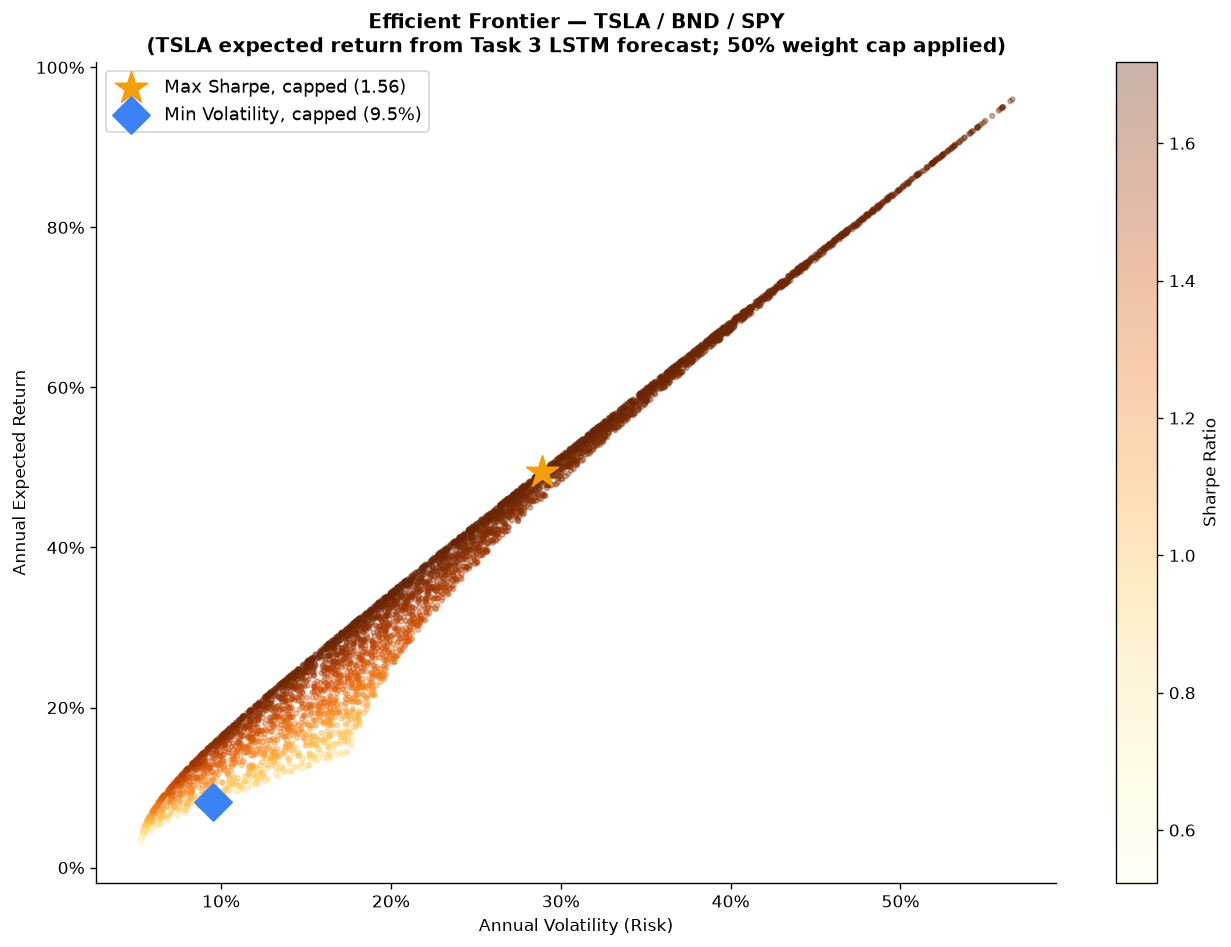

In [19]:
cloud = monte_carlo_cloud(mu_vec, cov_matrix, TICKERS, n=5000)

fig, ax = plt.subplots(figsize=(11, 8))
sc = ax.scatter(cloud['vols'], cloud['returns'], c=cloud['sharpes'],
                 cmap='YlOrBr', alpha=0.35, s=8)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio')

ms = results_capped['max_sharpe']
mv = results_capped['min_vol']
ax.scatter(ms['volatility'], ms['return'], s=400, marker='*', color='#F59E0B',
           zorder=5, label=f"Max Sharpe, capped ({ms['sharpe']:.2f})")
ax.scatter(mv['volatility'], mv['return'], s=250, marker='D', color='#3B82F6',
           zorder=5, label=f"Min Volatility, capped ({mv['volatility']*100:.1f}%)")

ax.set_title('Efficient Frontier — TSLA / BND / SPY\n(TSLA expected return from Task 3 LSTM forecast; 50% weight cap applied)',
              fontsize=12, fontweight='bold')
ax.set_xlabel('Annual Volatility (Risk)')
ax.set_ylabel('Annual Expected Return')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## Section 7 — Save Results for Task 5 Backtest

In [20]:
save_portfolio_results({
    'unconstrained': results_unconstrained,
    'capped': results_capped,
})
print('\nUse the capped Max Sharpe weights as the starting portfolio for the Task 5 backtest.')

  Saved -> data/processed/portfolio_optimization_results.csv

Use the capped Max Sharpe weights as the starting portfolio for the Task 5 backtest.
